<a href="https://colab.research.google.com/github/Lochan-01/ml/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd #data manipulation
import numpy as np #mathematical operation
import seaborn as sns #data visualization
import matplotlib.pyplot as plt #data visualization

In [7]:
#Load the Data set
df= pd.read_csv('/content/netflix_titles.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.isnull().sum()
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
df.duplicated().sum() #to find duplicate values
print(df.duplicated().sum())
# df.drop this function is used to delete the duplicate value

0


In [11]:
#missing value treatment for "OBJECT" variable
df['director']=df['director'].fillna(df['director'].mode()[0])
df['cast']=df['cast'].fillna(df['cast'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['date_added']=df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['duration']=df['duration'].fillna(df['duration'].mode()[0])



In [12]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [13]:
#it will only include for the numerical value
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


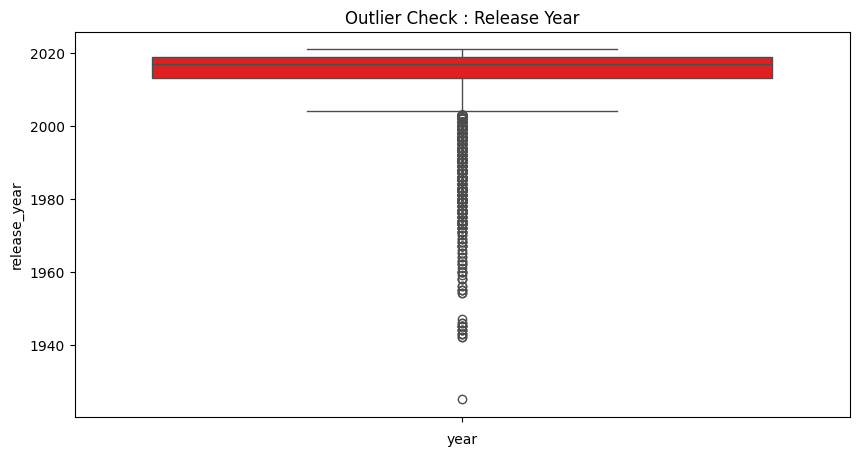

In [14]:
# outliers (this is also only for the numerical data)
plt.figure(figsize = (10,5))
sns.boxplot(df['release_year'],color='red')
plt.title("Outlier Check : Release Year")
plt.xlabel('year')
plt.show()



In [15]:
# capping the outliers
floor = df['release_year'].quantile(0.05)
df['release_year']=df['release_year'].clip(lower=floor)

In [16]:
#log transformation method to reduce impact of outlayers
df['release_year']=np.log(df['release_year'])

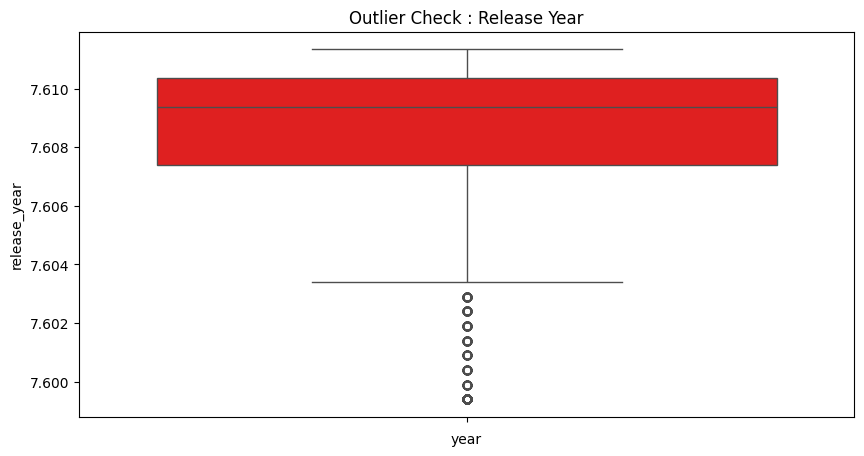

In [17]:
# outliers (this is also only for the numerical data)
plt.figure(figsize = (10,5))
sns.boxplot(df['release_year'],color='red')
plt.title("Outlier Check : Release Year")
plt.xlabel('year')
plt.show()

In [18]:
df.shape

(8807, 12)

In [19]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,float64
rating,object
duration,object


In [20]:
from sklearn.preprocessing import LabelEncoder
from numpy import astype

In [21]:
# convert all the object varible into numerical variable
# object -------> numerical
# 1.identify all 'object columns
object_cols=df.select_dtypes(include = ['object']).columns

# 2.Intialize the LabelEncoder
le= LabelEncoder()

# 3. Loop through coulmns and convert to int
for col in object_cols:
  df[col]=le.fit_transform(df[col].astype(str))

# Handle any float values
df=df.astype(int)

#check the results
print(df.dtypes)


show_id         int64
type            int64
title           int64
director        int64
cast            int64
country         int64
date_added      int64
release_year    int64
rating          int64
duration        int64
listed_in       int64
description     int64
dtype: object


In [23]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,0,1975,2295,1699,603,1711,7,7,210,274,2577
1,1111,1,1091,3392,409,426,1706,7,11,110,414,1762
2,2222,1,2651,2105,6296,603,1706,7,11,0,242,7341
3,3333,1,3506,3392,1699,603,1706,7,11,0,297,3617
4,4444,1,3861,3392,4815,251,1706,7,11,110,393,4416


In [25]:
df.corr()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,1.000000,-0.125233,0.108167,-0.066594,-0.014096,0.056135,-0.013414,NaN,-0.126742,0.091894,-0.071455,0.008412
type,-0.125233,1.000000,0.025439,0.361708,-0.020344,0.043375,-0.019628,NaN,0.290497,-0.380911,0.304750,0.021813
title,0.108167,0.025439,1.000000,0.005431,0.046241,0.017883,0.001662,NaN,-0.018155,-0.029824,0.017286,0.008079
director,-0.066594,0.361708,0.005431,1.000000,0.014789,0.007992,-0.010310,NaN,0.148489,-0.149808,0.084370,0.024134
cast,-0.014096,-0.020344,0.046241,0.014789,1.000000,-0.045449,-0.000501,NaN,-0.014393,-0.014241,-0.031809,-0.021298
country,0.056135,0.043375,0.017883,0.007992,-0.045449,1.000000,0.014104,NaN,-0.083319,0.088964,0.044170,0.043845
date_added,-0.013414,-0.019628,0.001662,-0.010310,-0.000501,0.014104,1.000000,NaN,0.010589,-0.002322,-0.009661,-0.002068
release_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,-0.126742,0.290497,-0.018155,0.148489,-0.014393,-0.083319,0.010589,NaN,1.000000,-0.019552,0.198433,0.038055
duration,0.091894,-0.380911,-0.029824,-0.149808,-0.014241,0.088964,-0.002322,NaN,-0.019552,1.000000,-0.049286,-0.006134


<Axes: >

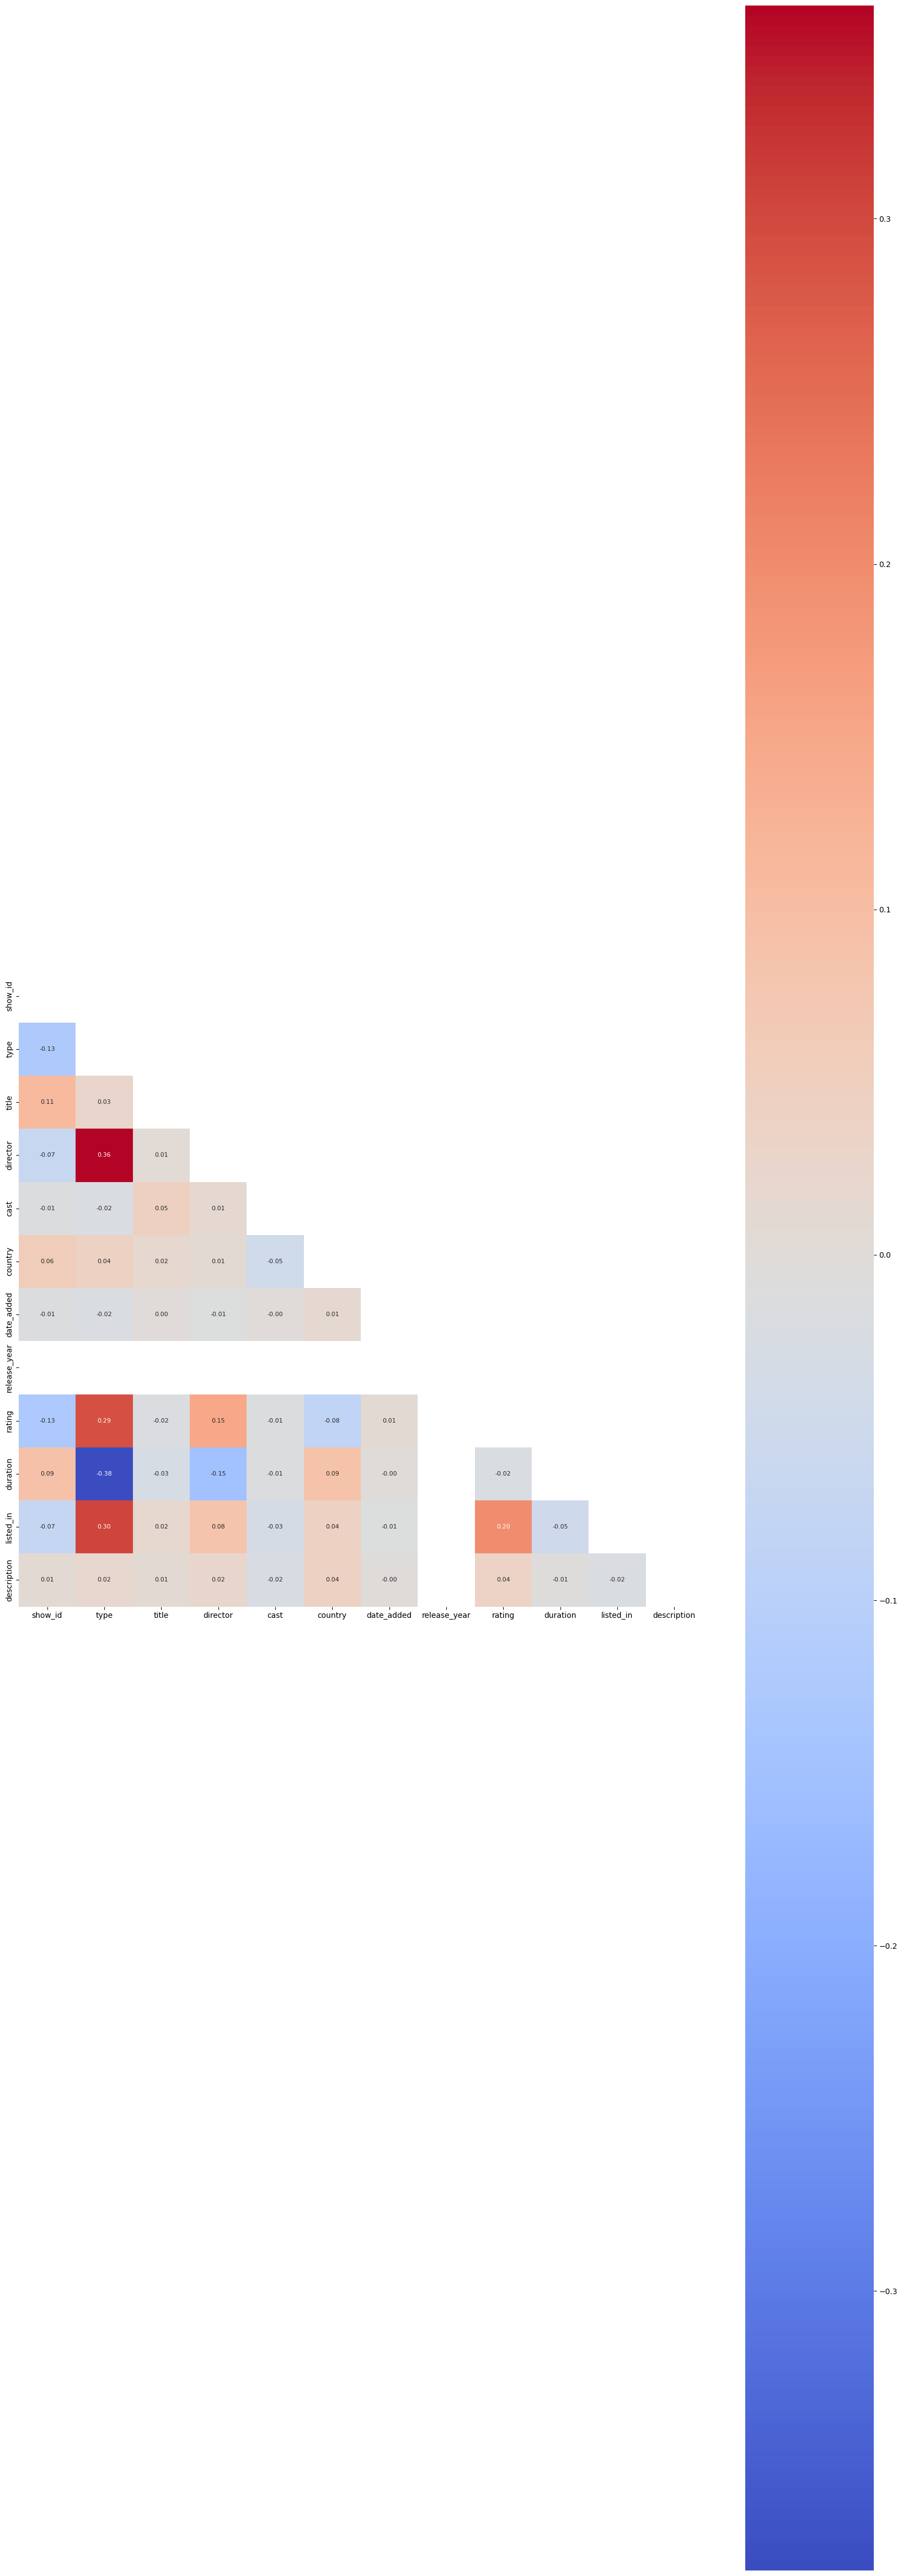

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

#Increase figure size
plt.figure(figsize=(20,15))

# 2.Focus on the most important co-relation
corr=df.corr()

# 3. create a mask to hide the top half
mask=np.triu(np.ones_like(corr))

# 4. Create a heatmap
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',annot_kws={"size":8},cbar_kws={"shrink":8})
#plt.title('correlation Heatmap',Fontsize =20)
#plt.xticks(rotation=45,ha='right')
#plt.show()

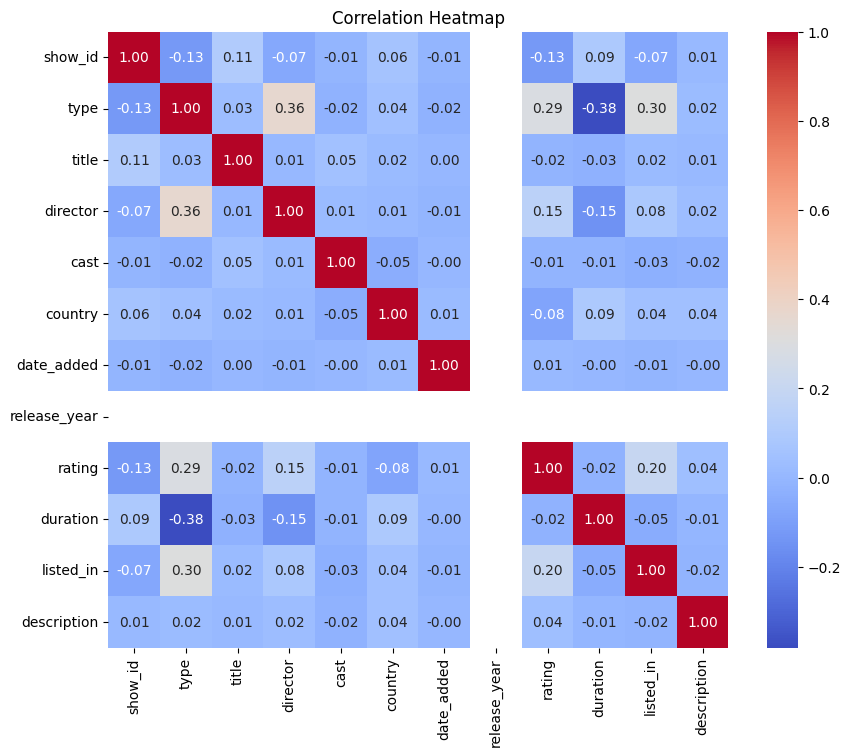

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

#calculate the correlation matrix
corr =df.corr()

#plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


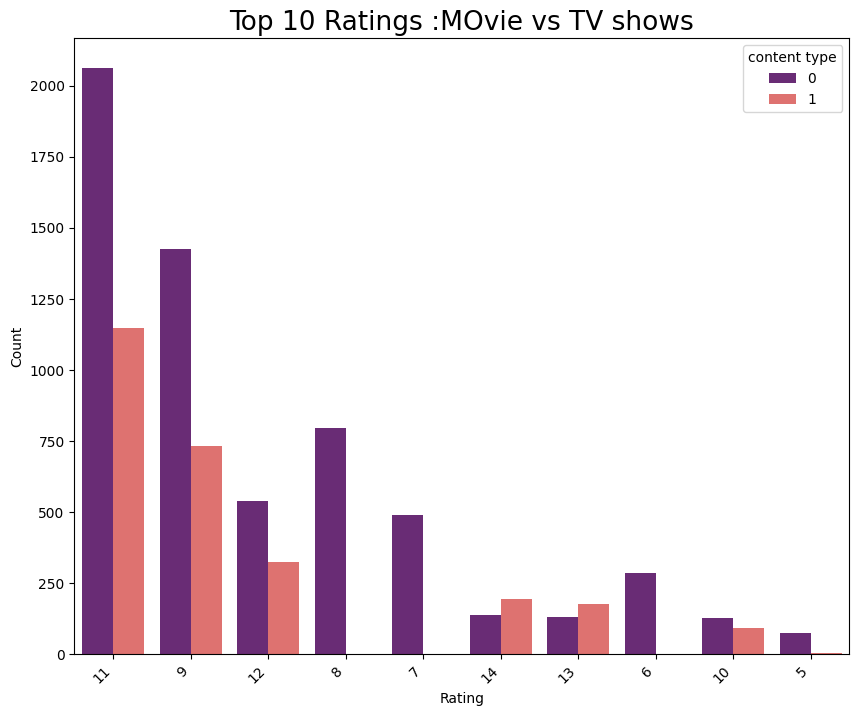

In [32]:
# Bi variate , univariate , Multivariable analysis
# prepare the data
top_ratings = df['rating'].value_counts().index[:10]
top_ratings_data = df[df['rating'].isin(top_ratings)]

#create the plot
plt.figure(figsize=(10,8))
sns.countplot(data= top_ratings_data,x='rating',hue='type',palette='magma',order=top_ratings)


#Aesthitics
plt.title('Top 10 Ratings :MOvie vs TV shows', fontsize=19)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title = 'content type')
plt.xticks(rotation=45,ha='right')
plt.show()